# Scientific plotting for publication with OmicVerse

In this tutorial, we focus on a practical question: **how to make biologically accurate, visually consistent, and publication-ready figures when using `omicverse`**.

This is not only an API tutorial. We will explain **what to do**, **why to do it**, and **which mistakes to avoid** when generating figures for manuscripts, preprints, and reports.

The core principles are:

- figures should communicate biology before decoration
- the same biological category should keep the same color across figures
- panel size, font, resolution, and export format should be standardized early
- continuous and categorical variables should use different color logic
- final figures should be exported in both raster and vector formats whenever possible

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import omicverse as ov

# Optional: use a processed AnnData object from your own analysis.
# adata = ...

# OmicVerse provides convenient styling helpers.
ov.plot_set(font_path='Arial')

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf
Registered as: Arial
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. Start from a reproducible visual standard

The first step in scientific plotting is **not plotting**. It is defining a reproducible visual baseline.

Why this matters:

- If you tune font size and panel size manually for every figure, the entire manuscript becomes inconsistent.
- If you save one figure at low resolution and another at high resolution, journal assembly becomes painful.
- If you decide colors only at the end, you usually break consistency across embeddings, heatmaps, and spatial panels.

A good default for compact manuscript figures is:

- single panel: `figsize=(4, 4)` or `figsize=(3, 3)`
- dense matrix or large embedding: `figsize=(8, 8)`
- final export: `dpi=300`
- crop white margins: `bbox_inches='tight'`
- save both `png` and `svg`

In [2]:
adata=ov.datasets.pbmc8k()

🩸 Downloading PBMC 8k dataset
Using Stanford mirror for pbmc8k
⚠️ File ./data/pbmc8k.h5ad already exists
 Loading data from ./data/pbmc8k.h5ad
✅ Successfully loaded: 7750 cells × 20939 genes


In [3]:
def set_publication_style(fontsize=12):
    plt.rcParams['figure.dpi'] = 80
    plt.rcParams['savefig.dpi'] = 300
    plt.rcParams['font.size'] = fontsize
    plt.rcParams['axes.labelsize'] = fontsize
    plt.rcParams['axes.titlesize'] = fontsize + 1
    plt.rcParams['xtick.labelsize'] = fontsize - 1
    plt.rcParams['ytick.labelsize'] = fontsize - 1
    plt.rcParams['legend.fontsize'] = fontsize - 1
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42


def save_figure_pair(stem):
    plt.savefig(f'{stem}.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{stem}.svg')
    #plt.savefig(f'{stem}.pdf')


set_publication_style(fontsize=13)

The helper above is written out so you can see what it sets. `omicverse` has
the same thing built in, and using it means one style rather than two: the
plotting functions read these rcParams instead of carrying their own defaults.

`ov.pl.font_sizes()` reports what the current settings resolve to, and
`ov.pl.style_axes(ax)` applies the frame convention the rest of `ov.pl` uses —
top and right spines hidden, the other two offset outward by 10 points.

In [4]:
ov.plot_set(fontsize=13)
ov.pl.font_sizes()

🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0
✅ plot_set complete.



{'label': 13.0, 'tick': 13.0, 'title': 13.0, 'legend': 11.96}

In [5]:
# rc_context here only so the notebook does not reprint the whole banner;
# in a script you would just call ov.plot_set(fontsize=...) once.
for size in (9, 13, 18):
    with plt.rc_context({'axes.labelsize': size, 'axes.titlesize': size + 2}):
        print(f"plot_set(fontsize={size:>2}) -> label {ov.pl.font_size(None, 'label'):>4.1f}"
              f"   title {ov.pl.font_size(None, 'title'):>4.1f}")

plot_set(fontsize= 9) -> label  9.0   title 11.0
plot_set(fontsize=13) -> label 13.0   title 15.0
plot_set(fontsize=18) -> label 18.0   title 20.0


left spine: ('outward', 10.0)


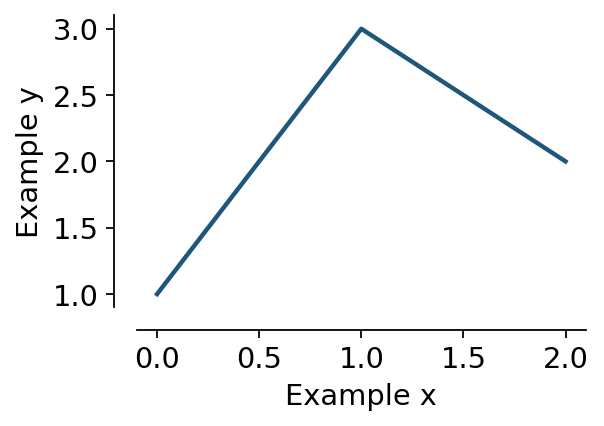

In [6]:
fig, ax = plt.subplots(figsize=(3.6, 2.4))
ax.plot([0, 1, 2], [1, 3, 2], lw=2)
ax.set_xlabel('Example x'); ax.set_ylabel('Example y')
ov.pl.style_axes(ax)
print("left spine:", ax.spines['left'].get_position())
plt.show()

## 2. Separate categorical color design from continuous color design

A common mistake is to use the same color logic for all figures.

This is incorrect because:

- **categorical annotations** such as cell types, clusters, niches, and samples require **stable named colors**
- **continuous values** such as scores, abundance, logFC, or expression require **ordered colormaps**

Purpose of this step:

- make the reader recognize the same biology instantly across multiple figures
- prevent visual misinterpretation caused by arbitrary remapping
- improve comparability between panels

Recommended rules:

- for cell types or clusters: build a dictionary once and reuse it everywhere
- for abundance-like values: start with `Reds`
- for signed effects such as enrichment or log fold change: start with `RdBu_r`

In [7]:
# Example: stable categorical palette.
# Replace 'cell_type' with your own annotation column.

if 'cell_type' in getattr(adata, 'obs', {}):
    categories = list(adata.obs['cell_type'].astype('category').cat.categories)
    palette = ov.pl.sc_color[8:] + ov.pl.red_color + ov.pl.orange_color + ov.pl.sc_color
    color_dict = {k: palette[i] for i, k in enumerate(categories)}
else:
    color_dict = {
        'T cell': '#279AD7',
        'B cell': '#F0A202',
        'Myeloid': '#E45756',
        'Stromal': '#54A24B',
    }

# Example: continuous colormap choices.
seq_cmap = 'Reds'      # abundance, score, density, expression intensity
signed_cmap = 'RdBu_r' # up/down, positive/negative, centered contrasts

## 3. Make embeddings readable before making them beautiful

UMAP, MDE, t-SNE, and spatial embeddings are often the first figures people see. Their purpose is usually **overview and orientation**, not decoration.

What this step should achieve:

- show the major biological structure clearly
- preserve category identity with stable colors
- remove unnecessary visual clutter

Good practice:

- use a compact square panel
- keep point size moderate
- remove oversized legends inside dense panels
- avoid changing palette order across figures
- use the same `basis` and annotation names consistently throughout the tutorial or manuscript

In [8]:
adata

AnnData object with n_obs × n_vars = 7750 × 20939
    obs: 'kit', 'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'predicted_celltype', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_name', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    obsm: 'UMAP', 'X_pca', 'X_umap'

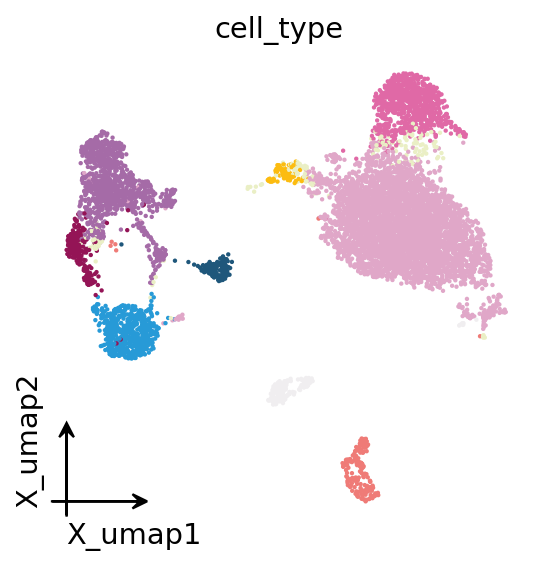

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


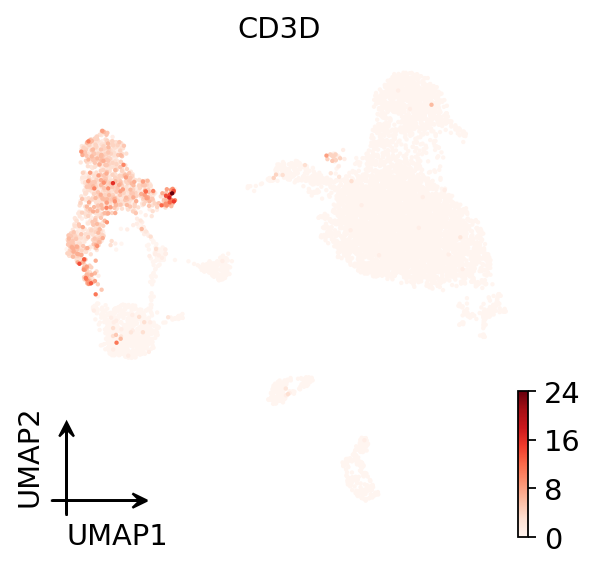

In [9]:
# Categorical embedding
fig, ax = plt.subplots(figsize=(4, 4))
ov.pl.embedding(
    adata,
    basis='X_umap',
    color='cell_type',
    #palette=color_dict,
    frameon='small',
    legend_loc=None,
    show=False,
    ax=ax,
)
save_figure_pair('figures/plotting/embedding_celltype')
plt.show()

# Continuous embedding
fig, ax = plt.subplots(figsize=(4, 4))
ov.pl.umap(
    adata,
    color='CD3D',
    cmap='Reds',
    frameon='small',
    show=False,
    ax=ax,
)
save_figure_pair('figures/plotting/embedding_module_score')
plt.show()

## 4. Use dotplots and violins to answer specific biological questions

Embeddings are useful for overview, but they are weak for exact comparison. When you need to compare **marker intensity**, **signature activity**, or **group differences**, use summary plots.

Why this step matters:

- dotplots compress many genes and groups into a readable panel
- violin plots expose distribution shape instead of only mean signal
- these plots provide stronger support for biological interpretation than embeddings alone

The goal is not to show more genes. The goal is to show the **right genes** with a **clear group order**.

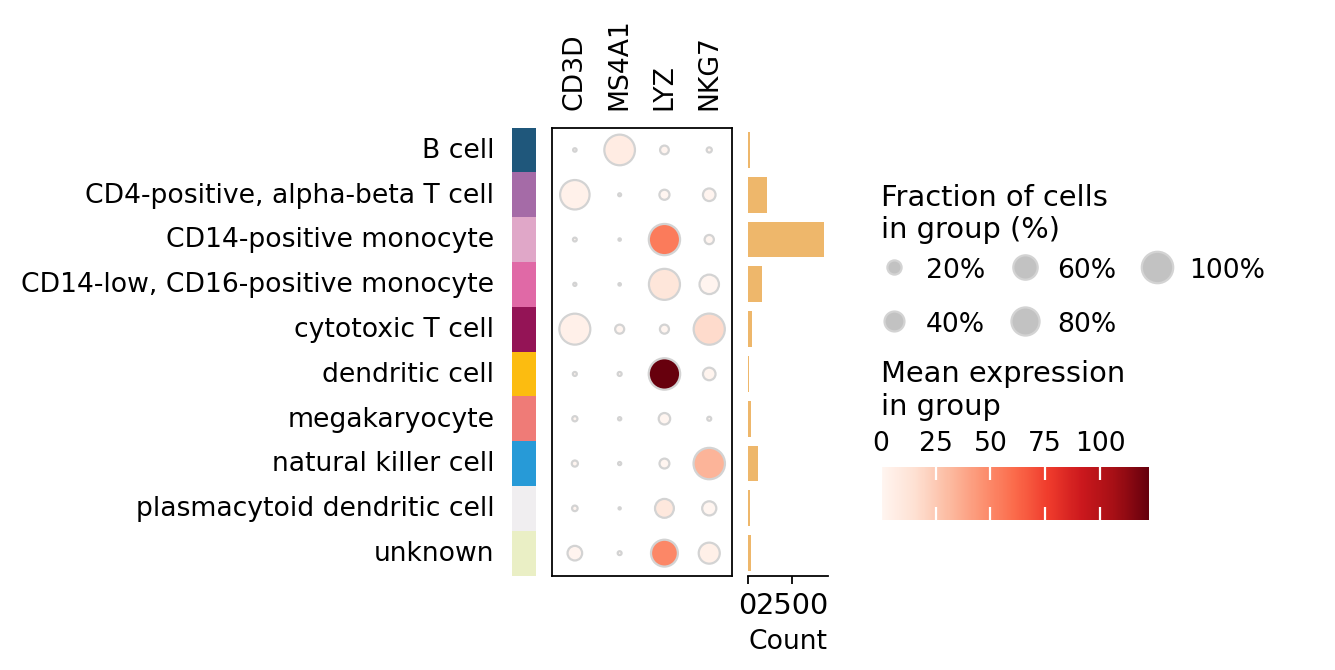

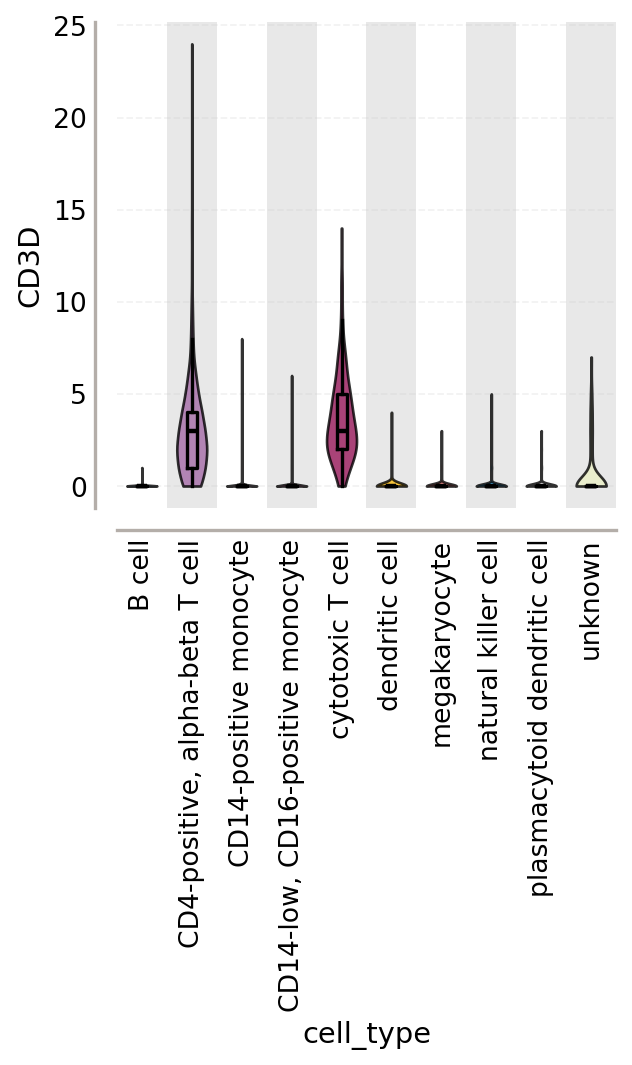

In [10]:
marker_genes = ['CD3D', 'MS4A1', 'LYZ', 'NKG7']

ov.pl.dotplot(
    adata,
    marker_genes,
    groupby='cell_type',
    cmap='Reds',
    figsize=(4, 4),
    show=False,
)
save_figure_pair('figures/plotting/dotplot_markers')
plt.show()

fig, ax = plt.subplots(figsize=(4, 4))
ov.pl.violin(
    adata,
    keys=['CD3D'],
    groupby='cell_type',
    rotation=90,
    stripplot=False,
    show=False,
    ax=ax,
    add_box=True
)
save_figure_pair('figures/plotting/violin_module_score')
plt.show()

## 5. Heatmaps should emphasize structure, not complexity

Heatmaps are powerful because they reveal coordinated patterns across groups. They are also easy to overcomplicate.

Purpose of this step:

- summarize structured differences across cell states, niches, or pathways
- make trends visible at a glance
- keep group-level interpretation readable

Recommended practice:

- cluster only when clustering adds information
- use diverging colormaps for centered values and sequential colormaps for abundance
- keep labels readable before increasing matrix size

In [11]:
# Example matrix: rows are categories, columns are features/pathways.
# Replace with your own summary matrix.
# matrix = ...

# sns.clustermap(
#     matrix,
#     cmap='RdBu_r',
#     figsize=(8, 8),
#     center=0,
# )
# plt.savefig('figures/plotting/heatmap_signed.png', dpi=300, bbox_inches='tight')
# plt.savefig('figures/plotting/heatmap_signed.svg', dpi=300, bbox_inches='tight')

## 6. Spatial plots should preserve tissue context while remaining interpretable

When plotting spatial transcriptomics or CosMx-style segmentation results, you should treat the image background as **context**, not as the main message.

Why this step matters:

- too much segmentation detail hides biology
- too much biological overlay hides tissue structure
- readers should be able to see both location and pattern without visual overload

Practical rules:

- keep panel shape close to square when possible
- use compact layouts such as `(4, 4)` for a single field of view
- keep contour lines and overlays visually subordinate
- reuse the same category colors used in embeddings and summary plots

In [12]:
# Template for segmented spatial plotting — omicverse has this natively,
# so no squidpy import is needed. Adjust the keys to your own AnnData;
# pbmc8k has no spatial coordinates, so this stays a template here.

# ov.pl.spatial_segment(
#     adata,
#     seg_cell_id='cell_ID',
#     color='cell_type',
#     library_key='fov',
#     library_id='1',
#     palette=color_dict,
#     img=False,
#     figsize=(4, 4),
#     legend_loc=None,
#     frameon='small',
#     show=False,
# )
# save_figure_pair('figures/plotting/spatial_segment_celltype')

# For a cell-boundary overlay coloured by a second variable, see
# ov.pl.spatial_segment_overlay; for polygon-based segmentation masks,
# ov.pl.spatialseg.

## 7. Export for both analysis and publication

Export is not a cosmetic afterthought. It determines whether your figure survives manuscript preparation.

Why save both formats:

- `png` is convenient for quick inspection, slides, and raster-based submissions
- `svg` is better for vector editing, journal layout, and text sharpness

Why `dpi=300` matters:

- below this, labels and small symbols often degrade in print or PDF assembly

Why `bbox_inches='tight'` matters:

- unnecessary margins complicate multi-panel composition

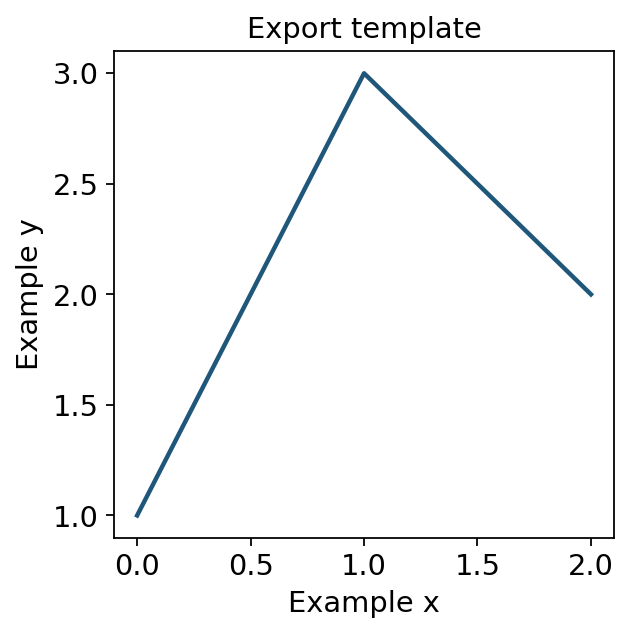

In [13]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot([0, 1, 2], [1, 3, 2], lw=2)
ax.set_xlabel('Example x')
ax.set_ylabel('Example y')
ax.set_title('Export template')
save_figure_pair('figures/plotting/export_template')
plt.show()

## 8. Assemble the panels

Everything so far produced *one* plot at a time. A manuscript figure is a
**composition**: several panels, at a width the journal specified, with `a` /
`b` / `c` tags in the margin, exported once.

Doing that by hand means `plt.subplots` plus `gridspec` plus a hand-placed
`ax.text` per panel, and the tags drift the moment the figure is resized
because they are positioned in axes fractions.

OmicVerse gives you **two layout engines**, and which one you want depends on
what the journal fixed:

| | you fix | it derives | use when |
|---|---|---|---|
| `ov.pl.multipanel` | the canvas (`width=`), or the panels (`panel_size=`) | the other one | the layout is a grid or a mosaic |
| `ov.pl.panelflow` | every panel's finished size | the canvas, by packing | panels differ in size and wrap into rows |

Both return axes **keyed by the letter printed on them**, so a panel is
referred to by what the reader sees, and both hand you plain matplotlib axes —
anything that takes `ax=` drops straight in.

Three things they do that a bare `plt.subplots` does not:

- **physical size**, in mm / cm / inches / points, or by journal preset —
  `width='nature-double'` is exactly 183 mm
- **tags offset in typographic points**, not axes fractions, so the same
  offset looks identical on a 40 mm and a 180 mm panel
- **decorations measured, not guessed** — tick labels and titles are reserved
  for at draw time, so a panel is the size you asked for

In [ ]:
fig, axes = ov.pl.multipanel((2, 2), width='nature-single', height=75)
print('figure size:', (fig.get_size_inches() * 25.4).round(1), 'mm')
print('panel keys :', list(axes))

### A 2 x 2 grid

The showcase layout: four panels, equal size, tagged `a`-`d` in reading
order. Nothing is placed by hand.

In [ ]:
# Short display names for the ontology labels, so tick labels stay readable.
SHORT = {
    'CD14-positive monocyte': 'CD14 Mono',
    'CD14-low, CD16-positive monocyte': 'CD16 Mono',
    'CD4-positive, alpha-beta T cell': 'CD4 T',
    'cytotoxic T cell': 'CD8 T',
    'natural killer cell': 'NK',
    'B cell': 'B',
    'plasmacytoid dendritic cell': 'pDC',
    'dendritic cell': 'DC',
    'megakaryocyte': 'Mk',
}

In [ ]:
frame = pd.DataFrame({
    'cell_type': adata.obs['cell_type'].map(SHORT).astype(str).to_numpy(),
    'n_genes': np.asarray((adata.X > 0).sum(axis=1)).ravel().astype(float),
    'CD3D': np.log1p(ov.pl.get_values(adata, 'CD3D')),
    'NKG7': np.log1p(ov.pl.get_values(adata, 'NKG7')),
}, index=adata.obs_names)
main = frame[frame['cell_type'] != 'nan']
print(main.shape, '|', main['cell_type'].nunique(), 'labelled types')
main.head(3).round(2)

In [ ]:
fig, ax = ov.pl.multipanel((2, 2), width='nature-double', height=115)
ov.pl.barplot(main, 'cell_type', 'n_genes', ax=ax['a'], rotation=45, fontsize=6,
              errorbar='ci', ylabel='genes detected')
ov.pl.violin(main, keys='CD3D', groupby='cell_type', ax=ax['b'], rotation=45, fontsize=6,
                 ylabel='log1p CD3D')
ov.pl.stripplot(main, 'cell_type', 'NKG7', ax=ax['c'], rotation=45, fontsize=6,
                size=2, jitter=0.28, alpha=0.4, ylabel='log1p NKG7')
ov.pl.donutplot(main, 'cell_type', ax=ax['d'], fontsize=5, legend=True,
                other_threshold=0.03)
plt.show()

### A 1 x 3 row, each panel titled

A row is the layout for "three views of the same thing". `label='A'` switches
to uppercase tags, which some journals require.

In [ ]:
fig, ax = ov.pl.multipanel((1, 3), width=180, height=58, label='A')
ov.pl.scatterplot(frame, 'n_genes', 'CD3D', density=True, ax=ax['A'], fontsize=6)
ov.pl.histplot(frame, 'n_genes', bins=40, ax=ax['B'], fontsize=6)
ov.pl.kdeplot(main, 'CD3D', hue='cell_type', ax=ax['C'], fontsize=6, legend=False)
for key, title in zip('ABC', ('Depth vs CD3D', 'Genes per cell', 'CD3D by type')):
    ax[key].set_title(title, fontsize=7)
plt.show()

### Unequal panels

Real figures rarely divide evenly. `width_ratios` and `height_ratios` size the
tracks; a mosaic string lets a panel **span** cells, with `.` leaving a gap.

`'AAB'` / `'CDB'` reads exactly as it looks: `A` spans the top-left two cells,
`B` spans the full height on the right, `C` and `D` sit underneath `A`.

Panels are reachable by the mosaic key **or** by the tag printed on them, so
`ax['A']` and `ax['a']` are the same axes here.

Note what panel **a** shows once `lineplot` is given a binned x: CD3D in CD4 T
cells climbs steadily with sequencing depth, while the non-T populations stay
flat at zero. That is a depth artefact, not biology — the kind of thing a
per-cell scatter hides and an aggregated trend with a confidence band makes
obvious.

In [ ]:
# lineplot aggregates repeated measurements at each x, so give it a binned x
# rather than one point per cell — here, sequencing-depth deciles.
trend = main.copy()
trend['depth_decile'] = pd.qcut(trend['n_genes'], 10, labels=False)
big = trend['cell_type'].value_counts().head(4).index
trend = trend[trend['cell_type'].isin(big)]

fig, ax = ov.pl.multipanel('AAB\nCDB', width='nature-double', height=95,
                           width_ratios=[1, 1, 1.3], label='a')
ov.pl.lineplot(trend, 'depth_decile', 'CD3D', hue='cell_type', ax=ax['A'],
               errorbar='ci', markers=True, fontsize=6, legend=False,
               xlabel='sequencing-depth decile', ylabel='log1p CD3D')
ov.pl.ridgeplot(main, 'n_genes', 'cell_type', ax=ax['B'], fontsize=6,
                overlap=0.7, xlabel='genes detected')
ov.pl.pieplot(main, 'cell_type', ax=ax['C'], fontsize=5,
              label_style='percent', other_threshold=0.05)
ov.pl.regplot(main, 'n_genes', 'NKG7', ax=ax['D'], fontsize=6, s=2,
              annotate=False, ylabel='log1p NKG7')
plt.show()

### When the journal specifies the *panel*, not the figure

"Each panel 45 mm wide" cannot be satisfied by fixing the canvas: what the
panel ends up as then depends on how much room the tick labels happened to
need. `panel_size` inverts the derivation — the panels are given, the canvas
follows.

`panel_widths` / `panel_heights` do the same per column and per row. Note that
`width=` and `panel_size=` are mutually exclusive: passing both is a
contradiction, and it is refused rather than silently resolved.

In [ ]:
fig, ax = ov.pl.multipanel((2, 2), panel_size=(45, 35), units='mm',
                           margins=10, spacing=6)
ov.pl.violin(main, keys='CD3D', groupby='cell_type', ax=ax['a'], rotation=45, fontsize=6)
ov.pl.histplot(frame, 'n_genes', bins=40, ax=ax['b'], fontsize=6)
ov.pl.kdeplot(main, 'NKG7', hue='cell_type', ax=ax['c'], fontsize=6, legend=False)
ov.pl.regplot(main, 'n_genes', 'CD3D', ax=ax['d'], fontsize=6, s=2, annotate=False)

# the panels are exactly 45 x 35 mm, and the canvas came out of that
box = ax['a'].get_position()
print('panel a  :', round(box.width * fig.get_size_inches()[0] * 25.4, 1),
      'x', round(box.height * fig.get_size_inches()[1] * 25.4, 1), 'mm')
print('canvas   :', (fig.get_size_inches() * 25.4).round(1), 'mm',
      '  # 2*45 + 6 spacing + 2*10 margins = 116')
plt.show()

### Panels of different sizes that wrap — `ov.pl.panelflow`

A grid asks every panel in a row to share a height. When the panels genuinely
differ — a tall violin beside a small pie, a wide bar chart above a donut —
that constraint is the wrong one, and `panelflow` drops it: **declare each
panel at its finished axes size**, and the engine packs them into rows,
wrapping when a row would exceed `max_width`, then reports the canvas it
needed.

Two things make it usable for a real figure:

- `below='A'` stacks a panel underneath another instead of continuing the row,
  which is how a small pie sits under a wide bar chart
- decorations are **measured at draw time** (`ax.get_tightbbox`) and reserved
  *outside* the declared box, so a 45 mm panel is 45 mm of data — the tick
  labels do not eat into it

`units='pt'` is worth knowing: point-based panel specs are common (a "45 x 100"
panel in a points-based tool is 16 x 35 mm, not 45 x 100 mm), and reading such
a spec as millimetres inflates every panel by 2.8x.

`reserve` chooses how much is measured. `'tight'` (default) reserves for
everything the axes draws, including a legend thrown outside it — safe. `'axis'`
reserves only for the tick labels, axis labels and title, which packs tighter
but lets a far-flung legend land on its neighbour.

In [ ]:
fl = ov.pl.panelflow(max_width=180, units='mm', reserve='axis',
                     title='Figure 2', title_kw={'fontweight': 'bold'})

a = fl.panel('A', 52, 42)
ov.pl.barplot(main, 'cell_type', 'n_genes', ax=a, rotation=45, fontsize=6,
              errorbar='ci', ylabel='genes detected')

# B sits *under* A rather than continuing the row
b = fl.panel('B', 52, 30, below='A')
ov.pl.pieplot(main, 'cell_type', ax=b, fontsize=5, other_threshold=0.05)

c = fl.panel('C', 58, 74)
ov.pl.violin(main, keys='CD3D', groupby='cell_type', ax=c, rotation=45, fontsize=6)

d = fl.panel('D', 58, 74)
ov.pl.regplot(main, 'n_genes', 'NKG7', ax=d, fontsize=6, s=2, annotate=False)

fl.fig.canvas.draw()
print('canvas packed to:', (fl.fig.get_size_inches() * 25.4).round(1), 'mm')
# the declared size is the *data* rectangle, decorations excluded
box = a.get_position()
print('panel A data box:', round(box.width * fl.fig.get_size_inches()[0] * 25.4, 1),
      'x', round(box.height * fl.fig.get_size_inches()[1] * 25.4, 1), 'mm')
plt.show()

### Making a plot behave as a panel

A function that draws beautifully on its own can still fight a layout. Two
cases worth knowing, because both are silent:

- **`roc` fixes a square aspect.** That is right for a standalone ROC — the
  chance line runs at 45° — but matplotlib honours it by shrinking the axes to
  a square *inside* whatever rectangle the layout assigned, so the panel stops
  filling its cell and its x-axis lifts off the row's baseline. `aspect='auto'`
  keeps the rectangle it was given.
- **jittered points are noise at panel scale.** `boxplot(show_points=False)`
  draws the boxes alone.

`volcano` has the same character of problem in its defaults: the threshold
guides used to be 2 pt solid black, which at panel scale reads as the panel's
content rather than as an annotation. They are now a thin grey dash and are
stylable, and the legend accounts for the non-significant points — usually the
majority — instead of listing only up and down.

In [ ]:
deg = ov.pl.compare_groups(main, 'CD3D', 'cell_type')     # a tidy result table
print(deg.head(3).round(4))

fig, ax = ov.pl.multipanel((1, 3), width=180, height=52, label='a')

# ROC: give up the square so the panel fills its cell
labels = (main['cell_type'] == 'CD4 T').to_numpy().astype(int)
ov.pl.roc(y_true=labels, y_score=main['CD3D'].to_numpy(), ax=ax['a'],
          ci=None, aspect='auto', fontsize=6)

# boxes without the jitter cloud
ov.pl.boxplot(data=main, x='cell_type', y='n_genes', hue='cell_type',
              ax=ax['b'], fontsize=6, show_points=False)
ax['b'].get_legend().remove()

# significance brackets on top of an existing categorical panel
ov.pl.violin(main, keys='NKG7', groupby='cell_type', ax=ax['c'], rotation=45,
             fontsize=6)
ov.pl.add_stat_annotation(ax['c'], main, 'NKG7', 'cell_type',
                          pairs=[('CD4 T', 'NK')], style='star', fontsize=6)
plt.show()

### Text that survives a small panel

Text is where panels break. Both of these are about the same thing — a label
that was fine at full size and is not at 40 mm — and both measure the drawn
geometry rather than guessing from the data.

**`ov.pl.declutter_ticks`** separates tick labels that collide. It tries, in
order: rotate, deal alternate labels into two rows, **slide them apart along
the axis with a thin leader back to each tick**, and only then show fewer of
them. Font sizes are never changed. The sliding step is the tick-label form of
what `adjust_text` does for point labels — a displaced label would point at the
wrong value on its own, and the leader is what makes moving it honest.

It runs as a draw-time callback, because whether labels collide depends on the
size the axes *ends up* at, which the plotting call cannot know. `style_axes`
registers it, so every `ov.pl` plot gets the pass for free; turn it off with
`ov.pl.set_tick_declutter(False)` globally or `style_axes(declutter=False)` per
axes.

**`ov.pl.adjust_text`** repels free-floating labels — gene names on a volcano,
say. Unlike the packaged `adjustText` it **clamps every label inside the
axes**, which is what makes it safe to call *after* a layout engine has resized
the panel: measured on a 64 x 78 mm volcano, the packaged version put eight
gene labels at data-y ≈ −6 against a y-limit of −0.5, i.e. off the canvas.

In [ ]:
fig, ax = ov.pl.multipanel((1, 2), width=150, height=48, label='a')

# a deliberately cramped categorical axis: the labels are separated at draw time
ov.pl.barplot(main, 'cell_type', 'n_genes', ax=ax['a'], fontsize=7,
              errorbar='ci', ylabel='genes detected')

# point labels repelled, but never leaving the panel
ov.pl.scatterplot(main, 'n_genes', 'CD3D', ax=ax['b'], fontsize=6, s=2)
picked = main.nlargest(6, 'CD3D')
texts = [ax['b'].text(r.n_genes, r.CD3D, name[:6], fontsize=5)
         for name, r in picked.iterrows()]
ov.pl.adjust_text(texts, ax=ax['b'], arrow_color='0.6', arrow_lw=0.4)

fig.canvas.draw()
inside = all(ax['b'].get_ylim()[0] <= t.get_position()[1] <= ax['b'].get_ylim()[1]
             for t in texts)
print('every gene label inside the panel:', inside)
plt.show()


### A clustered heatmap as one panel — `rect=`

`ov.pl.heatmap` draws a marsilea heatmap: dendrograms, annotation strips, row
labels, colour bar and legends, all in vector.

marsilea owns its own layout, though — it derives a figure size from its
content, resizes whatever figure it is handed, and places its axes as fractions
of *that*. Hand it a host figure and the heatmap takes the whole canvas. `rect`
is how it becomes a panel: the heatmap cell is sized so the whole block fills
the region you name, the block is **translated** into place (never rescaled, so
tick labels and legends keep the size they were drawn at), and the host
figure's size is restored.

The alternative — rendering the heatmap to a raster and `imshow`-ing it — loses
the vector text, which is the thing that made the export editable.

In [ ]:
# rows = cell types, columns = genes: a small matrix to cluster
genes = ['CD3D', 'CD3E', 'IL7R', 'MS4A1', 'CD79A', 'LYZ', 'S100A8', 'NKG7', 'GNLY']
present = [g for g in genes if g in adata.var_names]
mat = pd.DataFrame({g: np.log1p(ov.pl.get_values(adata, g)) for g in present},
                   index=adata.obs_names)
mat['cell_type'] = adata.obs['cell_type'].map(SHORT).astype(str).to_numpy()
mat = mat[mat['cell_type'] != 'nan'].groupby('cell_type').mean()

fig = ov.pl.figure(180, 105)
top = fig.add_axes([0.09, 0.66, 0.36, 0.28])
ov.pl.violin(main, keys='CD3D', groupby='cell_type', ax=top, rotation=45, fontsize=6)
ov.pl.add_panel_label(top, 'a', dx=-26, dy=4)

ov.pl.heatmap(mat, figure=fig, rect=(0.08, 0.05, 0.86, 0.50),
              z_score=1, cmap='RdBu_r',
              row_cluster=True, col_cluster=True, row_dendrogram=True,
              show_rownames=True, show_colnames=True,
              xlabel='marker', ylabel='cell type', label='Z-score')
fig.text(0.02, 0.56, 'b', fontweight='bold', fontsize=9)

print('host figure size kept:', (fig.get_size_inches() * 25.4).round(1), 'mm')
plt.show()

### Flows and paired designs

Two panel types that a grid of scatter plots cannot express:

- **`ov.pl.sankey`** — how rows redistribute between two or more categorical
  columns. Ribbon widths leaving a node sum back to the node's height, so the
  picture accounts for every row; the ribbon profile is the pySankey/cnsplots
  double-box convolution, which leaves the flow flat where it meets each node.
- **`ov.pl.slopeplot(group=...)`** — two conditions paired *within* each of
  several groups, one line per subject coloured by direction. Without `group`
  the plot is a single cluster spanning every `x` level, which cannot express
  "before vs after inside each site".

In [ ]:
fig, ax = ov.pl.multipanel((1, 2), width=170, height=62, label='a')

# where do the cells of each type fall on sequencing depth?
flow = main.assign(depth=np.where(main['n_genes'] > main['n_genes'].median(),
                                  'deep', 'shallow'))
ov.pl.sankey(flow, ['cell_type', 'depth'], ax=ax['a'], label_fontsize=6)

# a paired design: the same subjects measured twice, within each site
rng = np.random.default_rng(0)
rows = []
for site in ['site1', 'site2', 'site3']:
    shift = {'site1': -0.6, 'site2': 0.0, 'site3': 0.9}[site]
    for k in range(12):
        base = rng.normal(2.0, 0.6)
        rows.append(dict(value=base, site=site, label='before', pair=f'{site}_{k}'))
        rows.append(dict(value=base + shift + rng.normal(0, 0.2),
                         site=site, label='after', pair=f'{site}_{k}'))
paired = pd.DataFrame(rows)

ov.pl.slopeplot(paired, x='label', y='value', subject='pair', group='site',
                order=['before', 'after'], ax=ax['b'], fontsize=6)
plt.show()

### Tagging a panel yourself

`ov.pl.add_panel_label` places a single tag, offset from the axes corner in
**points**. That is the difference from the usual `ax.text(-0.1, 1.05, 'a')`
idiom: at 40 mm the axes-fraction version sits on top of the y-label, and at
180 mm it floats away. The point offset does neither.

`ov.pl.take_legend_out` moves a legend clear of the data instead of shrinking
it into a corner.

In [ ]:
fig, ax = ov.pl.figure(120, 55, axes=True)
ov.pl.kdeplot(main, 'CD3D', hue='cell_type', ax=ax, fill=True, fontsize=7,
              legend=False)
ov.pl.add_panel_label(ax, 'e', dx=-30, dy=4)
ov.pl.take_legend_out(ax, loc='right', fontsize=6,
                      handles=ax.collections[:3],
                      labels=list(main['cell_type'].unique()[:3]))
plt.show()

### Figure 1, assembled and exported

Putting it together with the omics panels from the earlier sections. The whole
composition is one figure object, so it exports in one call — and
`ov.pl.savefig` keeps the text as **text** in the SVG, which is what makes the
labels editable in Illustrator or Inkscape later.

Note `bbox_inches=None`: the default `'tight'` crops to the drawn content,
which is convenient but silently changes the width you asked for. When a
journal specifies 183 mm, pass `None` and keep it.

In [ ]:
fig, ax = ov.pl.multipanel('AB\nCD', width='nature-double', height=140)
ov.pl.embedding(adata, basis='X_umap', color='cell_type', frameon='small',
                legend_loc=None, show=False, ax=ax['a'])
ov.pl.embedding(adata, basis='X_umap', color='CD3D', cmap='Reds',
                frameon='small', show=False, ax=ax['b'])
ov.pl.violin(main, keys='CD3D', groupby='cell_type', ax=ax['c'], rotation=45, fontsize=6)
ov.pl.barplot(main, 'cell_type', 'n_genes', ax=ax['d'], rotation=45, fontsize=6,
              errorbar='ci')
plt.show()

In [ ]:
paths = ov.pl.savefig(fig, 'figures/plotting/figure1',
                      formats=['pdf', 'svg', 'png'], dpi=300,
                      bbox_inches=None)
svg = open('figures/plotting/figure1.svg').read()
print('width kept       :', (fig.get_size_inches()[0] * 25.4).round(1), 'mm')
print('SVG has <text>   :', '<text' in svg)
print('no embedded raster:', '<image' not in svg)

### Choosing between the two engines

If you are coming from `cnsplots`, its `multipanel` is a flow builder: you call
`mp.panel('A', 70, 70)` and every panel carries its own size, wrapping at
`max_width`. `ov.pl.panelflow` is that model — same declaration style, plus
`below=` for stacking and measured reserves so the declared size is the data
rectangle rather than the data *plus* whatever the tick labels needed.

`ov.pl.multipanel` is the grid/mosaic model, and it now covers both directions:
fix the canvas with `width=` and let the panels divide it, or fix the panels
with `panel_size=` / `panel_widths=` and let the canvas follow.

A rough rule:

- **regular grid, and the figure width is the constraint** → `multipanel(width=...)`
- **regular grid, and the panel size is the constraint** → `multipanel(panel_size=...)`
- **panels of genuinely different sizes, wrapping into rows** → `panelflow`

Both produce a plain matplotlib figure, so they compose with every function
that accepts `ax=` and export through the same `ov.pl.savefig`.

## 9. A practical checklist before you finalize a figure

Before a figure enters a manuscript, verify the following:

1. **Biological meaning is clear**: the plot answers one question well.
2. **Category colors are stable**: the same cell type is not recolored in another panel.
3. **Colormap logic is correct**: sequential for abundance, diverging for signed contrasts.
4. **Text is readable**: labels are not oversized, but they also do not disappear after export.
5. **Panel geometry is consistent**: similar figures use similar figure sizes.
6. **Legends are under control**: present when needed, suppressed when redundant.
7. **Export is complete**: both `png` and `svg` are saved with `dpi=300`.
8. **The figure can stand alone**: title, axis labels, and color interpretation are understandable without code.

If a figure fails any of these checks, improve the figure before generating more figures.

## Summary

A good scientific figure in `omicverse` is not defined by complexity. It is defined by **consistency**, **semantic color usage**, **appropriate plot choice**, and **clean export**.

A useful working order is:

1. define global style
2. fix categorical palettes
3. choose the correct continuous colormap
4. make the overview plot
5. make the evidence plot
6. export in paired formats

Once you standardize these steps, your plotting workflow becomes faster, more reproducible, and much easier to maintain across a full project.